# House Prices: Understanding & Comparing Categorical Encoding Techniques



## 1. Setup

**Importing the libraries we need and pointing to the data files with variables, not by typing the path again every time we need it.**

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

pd.set_option('display.max_columns', 100)

TRAIN_PATH = 'train.csv'
TEST_PATH = 'test.csv'
TARGET_COLUMN = 'SalePrice'
ID_COLUMN = 'Id'

RANDOM_STATE = 42  


## 2. Loading and Inspecting the Data

**We load the training and test datasets into pandas DataFrames. Since MSSubClass contains numerical building classification codes that represent discrete categories rather than continuous quantities, we immediately convert its data type to a string. Finally, we check the dataset dimensions and preview the first few rows.**

In [2]:

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df['MSSubClass'] = train_df['MSSubClass'].astype(str)
test_df['MSSubClass'] = test_df['MSSubClass'].astype(str)
print(f'train_df shape: {train_df.shape}')
print(f'test_df shape : {test_df.shape}')
train_df.head()

train_df shape: (1460, 81)
test_df shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   str    
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   str    
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 3. Understanding the columns we need to encode

**Instead of hardcoding a list of column names, we detect the categorical (text/object) columns directly from the DataFrame's dtypes. This way, if the dataset changes slightly, the notebook still works.**

In [5]:
def get_categorical_columns(df, exclude=None):

    exclude = exclude or []
    return [col for col in df.columns
            if pd.api.types.is_string_dtype(df[col]) and col not in exclude]

categorical_columns = get_categorical_columns(train_df, exclude=[ID_COLUMN, TARGET_COLUMN])
print(f'Found {len(categorical_columns)} categorical columns')

cardinality = train_df[categorical_columns].nunique().sort_values(ascending=False)
cardinality.to_frame('unique_values')

Found 44 categorical columns


,unique_values
Neighborhood,25
Exterior2nd,16
Exterior1st,15
MSSubClass,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7


## 4. Cleaning categorical missing values (config-driven, not hardcoded row-by-row)

**We read directly from `data_description.txt` which columns use `NaN` to mean *'feature absent'*. We store that as one list — a single place to look, and a single place to change if needed — and apply it with one function instead of repeating the same `.fillna(...)` line over and over.**

In [6]:

NA_MEANS_NONE_COLUMNS = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]

def fill_structural_missing(df, columns, fill_value='None'):
  
    df = df.copy()
    present_columns = [c for c in columns if c in df.columns]
    df[present_columns] = df[present_columns].fillna(fill_value)
    return df

def fill_remaining_categorical(df, columns):

    df = df.copy()
    for col in columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_clean = fill_structural_missing(train_df, NA_MEANS_NONE_COLUMNS)
train_clean = fill_remaining_categorical(train_clean, categorical_columns)

test_clean = fill_structural_missing(test_df, NA_MEANS_NONE_COLUMNS)
test_clean = fill_remaining_categorical(test_clean, categorical_columns)

print('Remaining missing values in categorical columns (train):',
      train_clean[categorical_columns].isnull().sum().sum())

Remaining missing values in categorical columns (train): 0


## 5. Encoding techniques

###  Label Encoding

**How it works:** every unique category is assigned a whole number (0, 1, 2, ...), usually in alphabetical order. It's simple and doesn't add extra columns.

**Problem:** the model may interpret the numbers as having an order/size relationship that isn't real (e.g. is `'Gable' > 'Hip'` just because 2 > 1?). This makes it best suited to **tree-based models** (which don't assume numeric order matters the way linear models do) or to columns that only have 2 categories.

In [7]:
demo_column = 'RoofStyle' 

label_encoder = LabelEncoder()
demo_before = train_clean[demo_column].head(8).reset_index(drop=True)
demo_after = pd.Series(label_encoder.fit_transform(train_clean[demo_column]), name=demo_column).head(8)

print('Categories found:', list(label_encoder.classes_))
pd.DataFrame({'before': demo_before, 'after_label_encoding': demo_after})

Categories found: ['Flat', 'Gable', 'Gambrel', 'Hip', 'Mansard', 'Shed']


,before,after_label_encoding
0,Gable,1
1,Gable,1
2,Gable,1
3,Gable,1
4,Gable,1
5,Gable,1
6,Gable,1
7,Gable,1


### One-Hot Encoding

**How it works:** creates one new binary (0/1) column *per category*. A house with `RoofStyle = 'Gable'` gets a `1` in the `RoofStyle_Gable` column and `0` everywhere else.

**Benefit:** no false sense of order is introduced — every category is treated as equally 'different' from every other.

**Trade-off:** the number of columns grows with the number of categories. For a 25-category column like `Neighborhood`, that's 25 new columns from a single original column — this is called the **curse of dimensionality**.

In [8]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
demo_one_hot = one_hot_encoder.fit_transform(train_clean[[demo_column]].head(8))
one_hot_columns = one_hot_encoder.get_feature_names_out([demo_column])

pd.DataFrame(demo_one_hot, columns=one_hot_columns)

,RoofStyle_Gable
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
5,1.0
6,1.0
7,1.0


###  Ordinal Encoding (order-aware)

**How it works:** the same idea as Label Encoding — one integer per category — but **we choose the order ourselves** instead of letting alphabetical order decide. This is the correct choice for columns that have a genuine ranking, like the quality scores in this dataset.

**`data_description.txt` gives us the same 5-point quality scale for many columns: `Po (Poor) < Fa (Fair) < TA (Typical/Average) < Gd (Good) < Ex (Excellent)`. We define that scale **once** and reuse it for every column that follows it, instead of retyping the mapping for each column.**

In [9]:
QUALITY_SCALE = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

QUALITY_SCALE_COLUMNS = [
    'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond'
]
QUALITY_SCALE_WITH_NONE = ['BsmtQual', 'BsmtCond', 'PoolQC']

def build_ordinal_encoder(base_scale, has_none=False):
    order = (['None'] + base_scale) if has_none else base_scale
    return OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)

demo_quality_column = 'KitchenQual'
ordinal_encoder = build_ordinal_encoder(QUALITY_SCALE)
demo_ordinal = ordinal_encoder.fit_transform(train_clean[[demo_quality_column]].head(8))

pd.DataFrame({
    demo_quality_column: train_clean[demo_quality_column].head(8).reset_index(drop=True),
    'ordinal_code': demo_ordinal.flatten()
})

,KitchenQual,ordinal_code
0,Gd,3.0
1,TA,2.0
2,Gd,3.0
3,Gd,3.0
4,Gd,3.0
5,TA,2.0
6,Gd,3.0
7,TA,2.0


Notice the codes now genuinely increase with quality (`TA` → 2, `Gd` → 3, `Ex` → 4), which a Label Encoder would **not** guarantee, since it just follows alphabetical order (`Ex, Fa, Gd, Po, TA` → 0,1,2,3,4 — which would put `Ex`, the best rating, at 0!).

### Frequency Encoding

**How it works:** replace each category with *how often it appears* in the training data. Useful for high-cardinality nominal columns (like `Neighborhood`) where One-Hot would create too many columns, but there's no natural order to use Ordinal Encoding either.

**Trade-off:** two different categories that happen to appear the same number of times get the same code, which can lose information.

In [10]:
def fit_frequency_map(series):
    return series.value_counts(normalize=True).to_dict()

def apply_frequency_map(series, frequency_map, default=0.0):
    return series.map(frequency_map).fillna(default)

demo_freq_column = 'Neighborhood'
freq_map = fit_frequency_map(train_clean[demo_freq_column])
demo_freq_encoded = apply_frequency_map(train_clean[demo_freq_column], freq_map)

pd.DataFrame({
    demo_freq_column: train_clean[demo_freq_column].head(8).reset_index(drop=True),
    'frequency_encoded': demo_freq_encoded.head(8).reset_index(drop=True)
})

,Neighborhood,frequency_encoded
0,CollgCr,0.102740
1,Veenker,0.007534
2,CollgCr,0.102740
3,Crawfor,0.034932
4,NoRidge,0.028082
5,Mitchel,0.033562
6,Somerst,0.058904
7,NWAmes,0.050000


### Target Encoding (mentioned for completeness — used carefully)

**How it works:replace each category with the average target value (average `SalePrice`) for that category. This can be very powerful because it directly encodes 'how much does this category typically affect the price', but it carries a real risk: data leakage — if computed on the full training set and then used to train on that same set, the model can 'cheat' by learning target values it shouldn't have access to.**


In [11]:
def fit_target_map(series, target):
    return target.groupby(series).mean().to_dict()

demo_target_column = 'Neighborhood'
target_map = fit_target_map(train_clean[demo_target_column], train_clean[TARGET_COLUMN])
demo_target_encoded = train_clean[demo_target_column].map(target_map)

pd.DataFrame({
    demo_target_column: train_clean[demo_target_column].head(8).reset_index(drop=True),
    'avg_SalePrice_for_category': demo_target_encoded.head(8).reset_index(drop=True).round(0)
})

,Neighborhood,avg_SalePrice_for_category
0,CollgCr,197966.0
1,Veenker,238773.0
2,CollgCr,197966.0
3,Crawfor,210625.0
4,NoRidge,335295.0
5,Mitchel,156270.0
6,Somerst,225380.0
7,NWAmes,189050.0


## 6. Presenting different encoding **pathways**

**A pathway here means: one complete, consistent strategy for encoding every categorical column in the dataset. We define three pathways below. Each is expressed as a small config `dict` plus one shared function that applies it — so adding a fourth pathway later just means adding one more config, not copy-pasting code.**

In [12]:
def split_columns_by_cardinality(columns, cardinality, low_cardinality_max):
  
    low = [c for c in columns if cardinality[c] <= low_cardinality_max]
    high = [c for c in columns if cardinality[c] > low_cardinality_max]
    return low, high

LOW_CARDINALITY_MAX = 10  

ordinal_quality_columns = QUALITY_SCALE_COLUMNS + QUALITY_SCALE_WITH_NONE
nominal_columns = [c for c in categorical_columns if c not in ordinal_quality_columns]
low_card_nominal, high_card_nominal = split_columns_by_cardinality(
    nominal_columns, cardinality, LOW_CARDINALITY_MAX
)

print(f'Ordinal (quality-scale) columns : {len(ordinal_quality_columns)}')
print(f'Low-cardinality nominal columns : {len(low_card_nominal)}')
print(f'High-cardinality nominal columns: {len(high_card_nominal)} -> {high_card_nominal}')

Ordinal (quality-scale) columns : 10
Low-cardinality nominal columns : 30
High-cardinality nominal columns: 4 -> ['MSSubClass', 'Neighborhood', 'Exterior1st', 'Exterior2nd']


**Pathway A — 'Best practice' mixed encoding**
Ordinal encoding for the quality-scale columns (keeps their order), One-Hot for low-cardinality nominal columns, Frequency encoding for the few high-cardinality nominal columns (keeps column count manageable).

**Pathway B — Label-encode everything**
The simplest possible approach: every categorical column, regardless of type, gets Label Encoded. Fast and compact, but ignores order where it matters and implies order where it doesn't.

**Pathway C — One-Hot everything**
The most 'information-preserving' approach for nominal data: One-Hot Encode every categorical column, including high-cardinality ones. Keeps all distinctions, at the cost of many extra columns.

In [13]:
def apply_pathway_A(df, freq_maps=None, fit=True):
    df = df.copy()
    freq_maps = freq_maps or {}

    for col in QUALITY_SCALE_COLUMNS:
        encoder = build_ordinal_encoder(QUALITY_SCALE, has_none=False)
        df[col] = encoder.fit_transform(df[[col]])
    for col in QUALITY_SCALE_WITH_NONE:
        encoder = build_ordinal_encoder(QUALITY_SCALE, has_none=True)
        df[col] = encoder.fit_transform(df[[col]])

    df = pd.get_dummies(df, columns=low_card_nominal, drop_first=False)

    for col in high_card_nominal:
        if fit:
            freq_maps[col] = fit_frequency_map(df[col])
        df[col] = apply_frequency_map(df[col], freq_maps[col])

    return df, freq_maps

def apply_pathway_B(df):
    df = df.copy()
    for col in categorical_columns:
        df[col] = LabelEncoder().fit_transform(df[col])
    return df

def apply_pathway_C(df):
    return pd.get_dummies(df, columns=categorical_columns, drop_first=False)

In [14]:
pathway_A_df, freq_maps_A = apply_pathway_A(train_clean)
pathway_B_df = apply_pathway_B(train_clean)
pathway_C_df = apply_pathway_C(train_clean)

pd.DataFrame({
    'pathway': ['A: mixed (ordinal + one-hot + frequency)', 'B: label-encode everything', 'C: one-hot everything'],
    'resulting_columns': [pathway_A_df.shape[1], pathway_B_df.shape[1], pathway_C_df.shape[1]]
})

,pathway,resulting_columns
0,A: mixed (ordinal + one-hot + frequency),211
1,B: label-encode everything,81
2,C: one-hot everything,318


## 7. Does the pathway actually matter? A quick model comparison

**To make the comparison concrete, we fit the same two simple models (Linear Regression and Random Forest) on each pathway's encoded training data, and compare cross-validated performance. Numeric columns are imputed with the median so encoding is the only thing varying between runs.**

In [15]:
def prepare_features(df, target_column, id_column):
    X = df.drop(columns=[target_column, id_column])
    y = df[target_column]
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    X[numeric_columns] = SimpleImputer(strategy='median').fit_transform(X[numeric_columns])
    return X, y

def evaluate_pathway(df, target_column, id_column, model, cv_folds=5, random_state=RANDOM_STATE):
    X, y = prepare_features(df, target_column, id_column)
    y_log = np.log1p(y)
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y_log, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean()

pathways = {
    'A: mixed': pathway_A_df,
    'B: label-encode all': pathway_B_df,
    'C: one-hot all': pathway_C_df,
}

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
}

results = []
for pathway_name, encoded_df in pathways.items():
    for model_name, model in models.items():
        rmse = evaluate_pathway(encoded_df, TARGET_COLUMN, ID_COLUMN, model)
        results.append({'pathway': pathway_name, 'model': model_name, 'cv_rmse_log_saleprice': round(rmse, 4)})

results_df = pd.DataFrame(results).sort_values('cv_rmse_log_saleprice')
results_df

,pathway,model,cv_rmse_log_saleprice
1,A: mixed,RandomForest,0.1432
3,B: label-encode all,RandomForest,0.1437
5,C: one-hot all,RandomForest,0.1444
4,C: one-hot all,LinearRegression,0.1532
0,A: mixed,LinearRegression,0.1554
2,B: label-encode all,LinearRegression,0.1649


In [27]:
from sklearn.model_selection import train_test_split

## 8. Choosing the best pathway and testing it properly

**Up to this point I only compared the three encoding pathways using cross-validation, which gives an average score but doesn't prove the model works on data it has never seen. Here I pick the pathway and model with the lowest error from my results table, then split that data into a training set and a separate test set that the model won't see during training.
This gives me an honest, final check later on.**

In [28]:
best_row = results_df.iloc[0]
best_pathway_name = best_row['pathway']
best_model_name = best_row['model']
print(f"Best pathway: {best_pathway_name} | Best model: {best_model_name}")
print(f"CV RMSE (log SalePrice): {best_row['cv_rmse_log_saleprice']}")

best_encoded_df = pathways[best_pathway_name]
X_best, y_best = prepare_features(best_encoded_df, TARGET_COLUMN, ID_COLUMN)
y_best_log = np.log1p(y_best)

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y_best_log, test_size=0.2, random_state=RANDOM_STATE
)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Best pathway: A: mixed | Best model: RandomForest
CV RMSE (log SalePrice): 0.1432
X_train shape: (1168, 209), X_test shape: (292, 209)


## 9. Training my final model

**I train the model I picked using only the training portion of my split. At this point the model has never seen the test portion, so anything I measure on it afterward is a fair test of how well the model generalizes.**

In [26]:
final_model = models[best_model_name]
final_model.fit(X_train, y_train)
y_pred_log = final_model.predict(X_test)


## 10. Checking how good my model actually is

**Since this is a regression problem (predicting a price, not a category), I can't use accuracy or a confusion matrix like a classification problem would. Instead I use RMSE and MAE, which tell me roughly how far off my predictions are on average, and R², which tells me what percentage of the price differences my model is able to explain. I calculate these both in log form (how the model was trained) and converted back to real dollar amounts (so the numbers actually mean something). I also plot predicted vs actual prices  the closer the points sit to the diagonal red line, the better my model is doing and a residual plot, which should look like random scatter with no obvious pattern if the model is behaving well.**

Holdout RMSE (log scale): 0.1445
Holdout MAE  (log scale): 0.0976
Holdout R^2:              0.8881
Holdout RMSE (dollars):   $29,432.08
Holdout MAE  (dollars):   $17,268.58


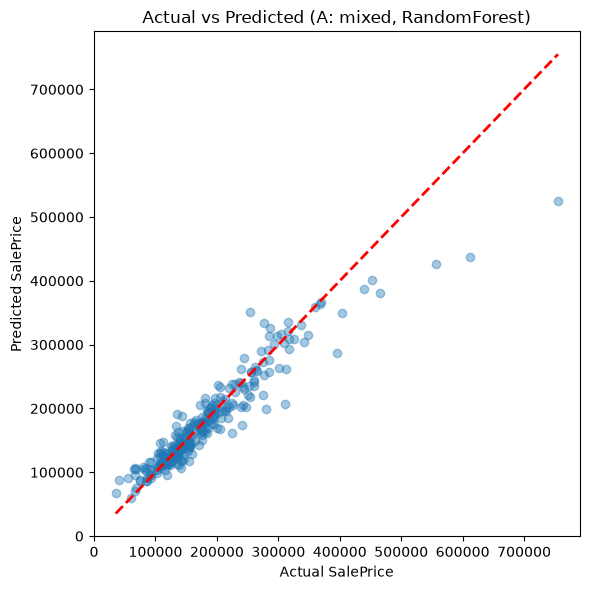

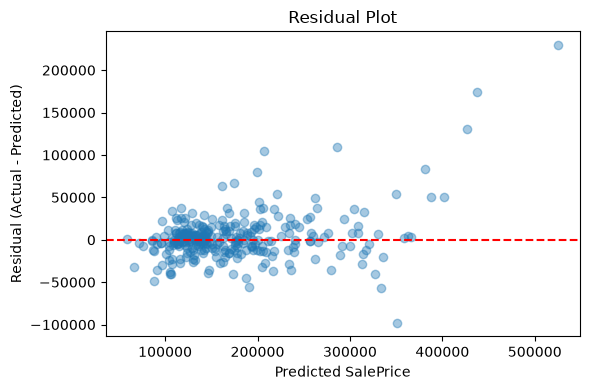

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)
rmse_dollars = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_dollars = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"Holdout RMSE (log scale): {rmse_log:.4f}")
print(f"Holdout MAE  (log scale): {mae_log:.4f}")
print(f"Holdout R^2:              {r2:.4f}")
print(f"Holdout RMSE (dollars):   ${rmse_dollars:,.2f}")
print(f"Holdout MAE  (dollars):   ${mae_dollars:,.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.4)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title(f'Actual vs Predicted ({best_pathway_name}, {best_model_name})')
plt.tight_layout()
plt.show()

residuals = y_test_actual - y_pred_actual
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_actual, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 11. Training on all my data and predicting the test set

**Now that I trust my model's performance, I retrain it one more time using all of my training data instead of holding some back, since more data usually makes a better final model. I then apply the exact same encoding steps to the real test set, make sure its columns line up exactly with what the model expects, fill in any missing values the same way I did for training, and generate my final predictions. Since my model was trained on log-transformed prices, I convert the predictions back to normal dollar values before saving them to `submission.csv`.**

In [30]:
final_model.fit(X_best, y_best_log)

if best_pathway_name == 'A: mixed':
    test_encoded_df, _ = apply_pathway_A(test_clean, freq_maps=freq_maps_A, fit=False)
elif best_pathway_name == 'B: label-encode all':
    test_encoded_df = apply_pathway_B(test_clean)
else:
    test_encoded_df = apply_pathway_C(test_clean)

test_encoded_df = test_encoded_df.reindex(columns=X_best.columns, fill_value=0)

numeric_cols_test = test_encoded_df.select_dtypes(include=[np.number]).columns
test_encoded_df[numeric_cols_test] = SimpleImputer(strategy='median').fit_transform(
    test_encoded_df[numeric_cols_test]
)

test_predictions_log = final_model.predict(test_encoded_df)
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    ID_COLUMN: test_df[ID_COLUMN],
    TARGET_COLUMN: test_predictions
})
submission.to_csv('submission.csv', index=False)
print("submission.csv written.")
submission.head()

submission.csv written.


,Id,SalePrice
0,1461,125398.933758
1,1462,154935.186815
2,1463,178356.389622
3,1464,183113.518844
4,1465,194852.631131
